SpectralSensitivity module loaded
Available names: ['__builtins__', '__file__', '__name__', '__nonzero__', 'blue', 'channels', 'channels_norm', 'colors', 'df', 'global_max', 'green', 'np', 'pd', 'red', 'wavelength_nm']
[1.24594214e+15 1.22621016e+15 1.20281980e+15 1.17648636e+15
 1.14784270e+15 1.11744291e+15 1.08576757e+15 1.05322985e+15
 1.02018189e+15 9.86921255e+14 9.53697107e+14 9.20716079e+14
 8.88147665e+14 8.56129141e+14 8.24770005e+14 7.94155919e+14
 7.64352221e+14 7.35406993e+14 7.07353759e+14 6.80213825e+14
 6.53998305e+14 6.28709873e+14 6.04344272e+14 5.80891593e+14
 5.58337385e+14 5.36663584e+14 5.15849309e+14 4.95871528e+14
 4.76705629e+14 4.58325882e+14 4.40705842e+14 4.23818667e+14
 4.07637394e+14 3.92135154e+14 3.77285353e+14 3.63061813e+14
 3.49438889e+14 3.36391553e+14 3.23895465e+14 3.11927020e+14
 3.00463383e+14]
[array([1.94457485e+12, 4.00153713e+12, 3.07190073e+12, 2.83772250e+12,
       2.76863308e+12, 2.53676028e+12, 5.08375847e+12, 2.08015884e+14,
       5.20

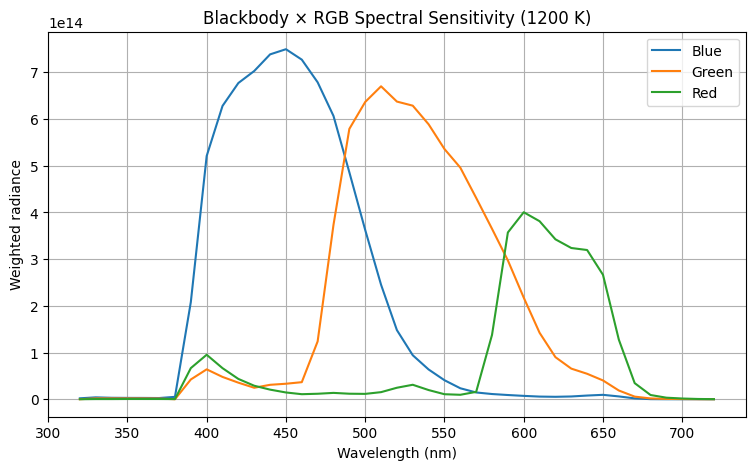

In [18]:
import numpy as np
import matplotlib.pyplot as plt
%run SpectralSensitivity.py
bb_emissivity = 1
C1= (0.59)*(10**(-16)) #W*m^2/sr
C2 = 0.01438769 # m*K
Temperature_bb = 10000
wavelength_m=wavelength_nm*(10**(-9))
bb_intensity = 2*np.pi*C1/((wavelength_m**5)*(np.exp(C2/(wavelength_m*Temperature_bb))-1))
print(bb_intensity)

lambda_function = {
    name : np.trapezoid(bb_emissivity*resp*bb_intensity, wavelength_m) for name, resp in channels_norm.items()
    }
print([bb_intensity*resp for resp in channels_norm.values()])
plt.figure(figsize=(9, 5))

for name, resp in channels_norm.items():
    plt.plot(
        wavelength_nm,
        bb_intensity * resp,
        label=name
    )

plt.xlabel("Wavelength (nm)")
plt.ylabel("Weighted radiance")
plt.title("Blackbody × RGB Spectral Sensitivity (1200 K)")
plt.legend()
plt.grid(True)
plt.show()
